In [1]:
# import libraries
import os
import glob
import random

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

# for importing/handling data
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

# for images
from PIL import Image

# for evaluation
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# reproducibility
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)


In [2]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


# Automatically pull my custom smartphone photos from GitHub

In [3]:

GITHUB_REPO_URL = 'https://github.com/sakib028/CNN.git'

REPO_DIR = 'CNN'

if not os.path.isdir(REPO_DIR):
    exit_code = os.system(f'git clone {GITHUB_REPO_URL} {REPO_DIR}')
    if exit_code != 0:
        print('WARNING: git clone failed. Set GITHUB_REPO_URL to your repo above.')
else:
    print(f'{REPO_DIR} already exists locally, skipping clone.')

CUSTOM_IMAGE_DIR = os.path.join(REPO_DIR, 'dataset')
MODEL_SAVE_DIR   = os.path.join(REPO_DIR, 'model')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

print('Custom images expected in:', CUSTOM_IMAGE_DIR)


Custom images expected in: CNN/dataset


# Import the standard dataset (CIFAR-10, filtered to 4 classes)

CIFAR-10 has 10 classes; we only need the 4 that match our custom photos:
`automobile`, `bird`, `cat`, `dog`.


In [4]:

TARGET_CLASSES = ['automobile', 'bird', 'cat', 'dog']


transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
full_devtest  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


all_classes   = full_trainset.classes
target_idx    = [all_classes.index(c) for c in TARGET_CLASSES]
old2new_label = {old: new for new, old in enumerate(target_idx)}

def filter_indices(dataset):
    return [i for i, lbl in enumerate(dataset.targets) if lbl in target_idx]

train_indices = filter_indices(full_trainset)
devtest_indices = filter_indices(full_devtest)

trainset = Subset(full_trainset, train_indices)
devtest  = Subset(full_devtest, devtest_indices)

# split the devtest into dev + test
randidx = np.random.permutation(len(devtest))
devset  = Subset(devtest, randidx[:len(randidx)//2])
testset = Subset(devtest, randidx[len(randidx)//2:])

# transform to dataloaders
batchsize    = 32
train_loader = DataLoader(trainset, batch_size=batchsize, shuffle=True, drop_last=True)
dev_loader   = DataLoader(devset,   batch_size=batchsize)
test_loader  = DataLoader(testset,  batch_size=len(testset))

print('Data sizes (train/dev/test):', len(trainset), len(devset), len(testset))
print('Target classes:', TARGET_CLASSES)


100%|██████████| 170M/170M [14:20<00:00, 198kB/s]


Data sizes (train/dev/test): 20000 2000 2000
Target classes: ['automobile', 'bird', 'cat', 'dog']


In [5]:
# sanity-check a batch and remap CIFAR-10's original labels -> 0..3
X, y_raw = next(iter(train_loader))
y = torch.tensor([old2new_label[int(v)] for v in y_raw])

print('Data shape (batch):', X.shape)
print('Data value range:', (torch.min(X).item(), torch.max(X).item()))
print('Example remapped labels:', y[:10].tolist())


Data shape (batch): torch.Size([32, 3, 32, 32])
Data value range: (-1.0, 1.0)
Example remapped labels: [1, 0, 3, 0, 0, 1, 3, 2, 0, 3]


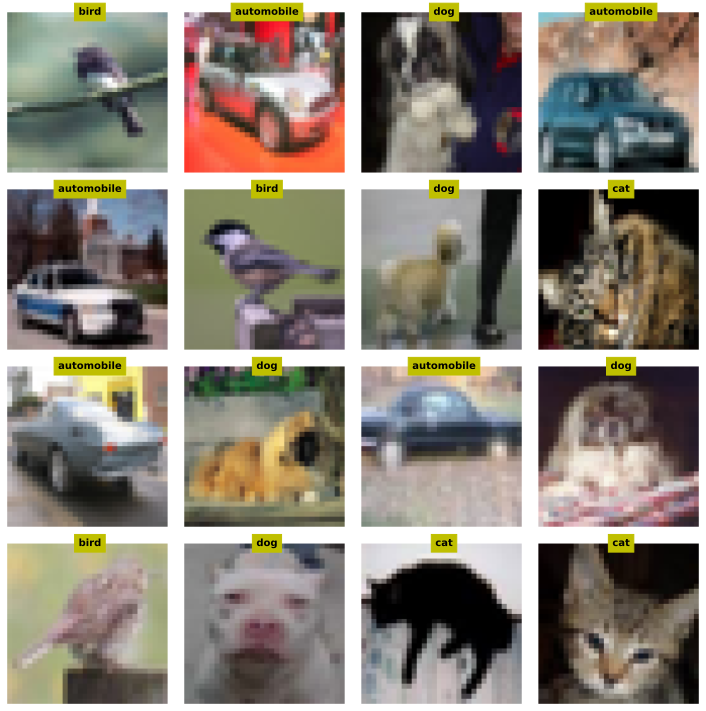

In [6]:
# inspect a few random training images
fig, axs = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axs.flatten()):
    pic = X[i].numpy().transpose((1, 2, 0))
    pic = pic / 2 + 0.5  # undo normalization

    label = TARGET_CLASSES[y[i]]

    ax.imshow(pic)
    ax.text(16, 0, label, ha='center', fontweight='bold', color='k', backgroundcolor='y')
    ax.axis('off')

plt.tight_layout()
plt.show()


# Create the CNN model

In [7]:
# create a function that builds the model, loss function, and optimizer
def makeTheNet(printtoggle=False, num_classes=len(TARGET_CLASSES)):

    class cnnnet(nn.Module):
        def __init__(self, printtoggle):
            super().__init__()

            self.print = printtoggle

            ### -------------- feature map layers -------------- ###
            self.conv1  = nn.Conv2d(3, 64, 3, padding=1)
            self.bnorm1 = nn.BatchNorm2d(64)
            # output size: (32+2*1-3)/1 + 1 = 32 -> /2 (maxpool) = 16

            self.conv2  = nn.Conv2d(64, 128, 3)
            self.bnorm2 = nn.BatchNorm2d(128)
            # output size: (16-3)/1 + 1 = 14 -> /2 = 7

            self.conv3  = nn.Conv2d(128, 256, 3)
            self.bnorm3 = nn.BatchNorm2d(256)
            # output size: (7-3)/1 + 1 = 5 -> /2 = 2

            ### -------------- linear decision layers -------------- ###
            self.fc1 = nn.Linear(2*2*256, 256)
            self.fc2 = nn.Linear(256, 64)
            self.fc3 = nn.Linear(64, num_classes)

        def forward(self, x):

            if self.print: print(f'Input: {list(x.shape)}')

            # block 1: convolution -> maxpool -> batchnorm -> relu
            x = F.max_pool2d(self.conv1(x), 2)
            x = F.leaky_relu(self.bnorm1(x))
            if self.print: print(f'First CPBR block: {list(x.shape)}')

            # block 2
            x = F.max_pool2d(self.conv2(x), 2)
            x = F.leaky_relu(self.bnorm2(x))
            if self.print: print(f'Second CPBR block: {list(x.shape)}')

            # block 3
            x = F.max_pool2d(self.conv3(x), 2)
            x = F.leaky_relu(self.bnorm3(x))
            if self.print: print(f'Third CPBR block: {list(x.shape)}')

            # reshape for linear layer
            nUnits = x.shape.numel() / x.shape[0]
            x = x.view(-1, int(nUnits))
            if self.print: print(f'Vectorized: {list(x.shape)}')

            # linear layers
            x = F.leaky_relu(self.fc1(x))
            x = F.dropout(x, p=0.5, training=self.training)
            x = F.leaky_relu(self.fc2(x))
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.fc3(x)
            if self.print: print(f'Final output: {list(x.shape)}')

            return x

    net = cnnnet(printtoggle)
    lossfun = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-5)

    return net, lossfun, optimizer


In [8]:
# test the model with one batch
net, lossfun, optimizer = makeTheNet(True)

X, y_raw = next(iter(train_loader))
y = torch.tensor([old2new_label[int(v)] for v in y_raw])

yHat = net(X)

print('\nOutput size:')
print(yHat.shape)

loss = lossfun(yHat, y)
print('\nLoss:', loss.item())


Input: [32, 3, 32, 32]
First CPBR block: [32, 64, 16, 16]
Second CPBR block: [32, 128, 7, 7]
Third CPBR block: [32, 256, 2, 2]
Vectorized: [32, 1024]
Final output: [32, 4]

Output size:
torch.Size([32, 4])

Loss: 1.3570226430892944


# Train the model

In [9]:
def function2trainTheModel(numepochs=10):

    net, lossfun, optimizer = makeTheNet()
    net.to(device)

    trainLoss = torch.zeros(numepochs)
    devLoss   = torch.zeros(numepochs)
    trainAcc  = torch.zeros(numepochs)
    devAcc    = torch.zeros(numepochs)

    for epochi in range(numepochs):

        # --- training ---
        net.train()
        batchLoss, batchAcc = [], []
        for X, y_raw in train_loader:
            y = torch.tensor([old2new_label[int(v)] for v in y_raw])
            X, y = X.to(device), y.to(device)

            yHat = net(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())
            batchAcc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())

        trainLoss[epochi] = np.mean(batchLoss)
        trainAcc[epochi]  = 100 * np.mean(batchAcc)

        # --- dev evaluation ---
        net.eval()
        batchLoss, batchAcc = [], []
        for X, y_raw in dev_loader:
            y = torch.tensor([old2new_label[int(v)] for v in y_raw])
            X, y = X.to(device), y.to(device)

            with torch.no_grad():
                yHat = net(X)
                loss = lossfun(yHat, y)

            batchLoss.append(loss.item())
            batchAcc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())

        devLoss[epochi] = np.mean(batchLoss)
        devAcc[epochi]  = 100 * np.mean(batchAcc)

        print(f'Epoch {epochi+1:2d}/{numepochs} | train loss {trainLoss[epochi]:.3f} acc {trainAcc[epochi]:.1f}% '
              f'| dev loss {devLoss[epochi]:.3f} acc {devAcc[epochi]:.1f}%')

    return trainLoss, devLoss, trainAcc, devAcc, net


In [10]:
# ~2 minutes with 10 epochs on GPU
trainLoss, devLoss, trainAcc, devAcc, net = function2trainTheModel(numepochs=10)


Epoch  1/10 | train loss 0.873 acc 61.8% | dev loss 0.661 acc 72.2%
Epoch  2/10 | train loss 0.661 acc 73.3% | dev loss 0.562 acc 77.2%
Epoch  3/10 | train loss 0.551 acc 78.3% | dev loss 0.523 acc 78.6%
Epoch  4/10 | train loss 0.465 acc 82.0% | dev loss 0.503 acc 79.2%
Epoch  5/10 | train loss 0.389 acc 85.2% | dev loss 0.499 acc 81.0%
Epoch  6/10 | train loss 0.326 acc 87.9% | dev loss 0.482 acc 81.2%
Epoch  7/10 | train loss 0.269 acc 89.8% | dev loss 0.552 acc 81.8%
Epoch  8/10 | train loss 0.215 acc 92.3% | dev loss 0.654 acc 80.9%
Epoch  9/10 | train loss 0.178 acc 93.7% | dev loss 0.603 acc 80.2%
Epoch 10/10 | train loss 0.149 acc 94.9% | dev loss 0.679 acc 82.7%


In [11]:
## evaluate on the held-out test set
net.eval()
X, y_raw = next(iter(test_loader))
y = torch.tensor([old2new_label[int(v)] for v in y_raw])

X, y = X.to(device), y.to(device)

with torch.no_grad():
    yHat = net(X)
    loss = lossfun(yHat, y)

testLoss = loss.item()
testAcc  = 100 * torch.mean((torch.argmax(yHat, axis=1) == y).float()).item()

print(f'Test loss: {testLoss:.3f} | Test accuracy: {testAcc:.2f}%')


Test loss: 0.606 | Test accuracy: 82.35%


# Training history: loss and accuracy vs. epochs

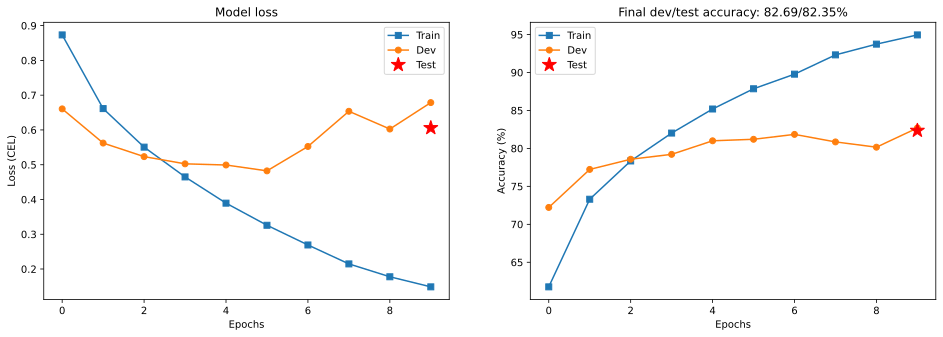

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(trainLoss, 's-', label='Train')
ax[0].plot(devLoss, 'o-', label='Dev')
ax[0].plot(len(devLoss) - 1, testLoss, 'r*', markersize=15, label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (CEL)')
ax[0].set_title('Model loss')
ax[0].legend()

ax[1].plot(trainAcc, 's-', label='Train')
ax[1].plot(devAcc, 'o-', label='Dev')
ax[1].plot(len(devAcc) - 1, testAcc, 'r*', markersize=15, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final dev/test accuracy: {devAcc[-1]:.2f}/{testAcc:.2f}%')
ax[1].legend()

plt.show()


# Confusion matrix (standard test set)

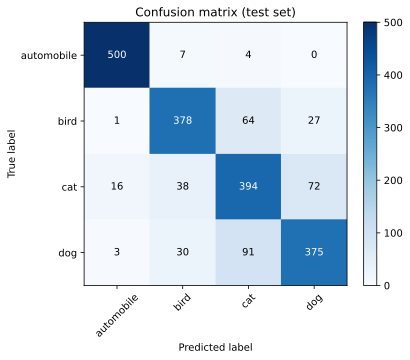

In [13]:
# run the full test set through the model
net.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X, y_raw in DataLoader(testset, batch_size=64):
        y = torch.tensor([old2new_label[int(v)] for v in y_raw])
        X = X.to(device)
        yHat = net(X)
        preds = torch.argmax(yHat, axis=1).cpu()

        all_preds.extend(preds.tolist())
        all_true.extend(y.tolist())

cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(TARGET_CLASSES)))
ax.set_yticks(range(len(TARGET_CLASSES)))
ax.set_xticklabels(TARGET_CLASSES, rotation=45)
ax.set_yticklabels(TARGET_CLASSES)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion matrix (test set)')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


# Visual error analysis: 3 misclassified test images

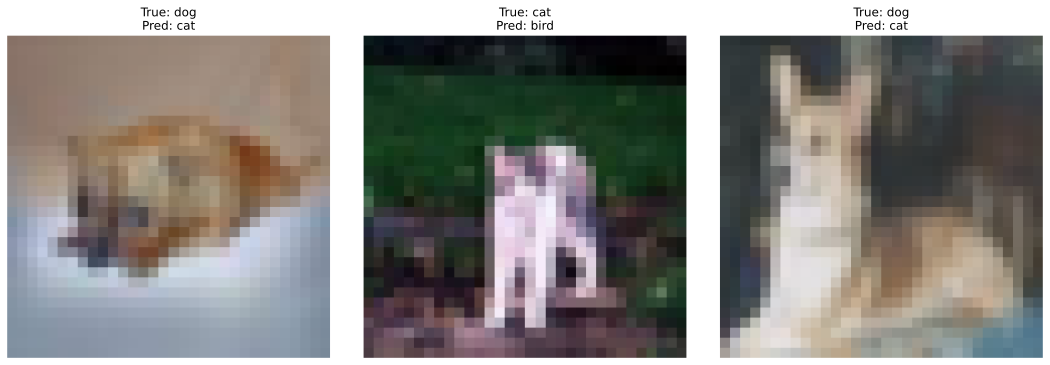

In [14]:
# collect images + preds + true labels for the whole test set
net.eval()
mis_images, mis_true, mis_pred = [], [], []

with torch.no_grad():
    for X, y_raw in DataLoader(testset, batch_size=64):
        y = torch.tensor([old2new_label[int(v)] for v in y_raw])
        Xg = X.to(device)
        yHat = net(Xg)
        preds = torch.argmax(yHat, axis=1).cpu()

        wrong = preds != y
        if wrong.any():
            mis_images.extend(X[wrong])
            mis_true.extend(y[wrong].tolist())
            mis_pred.extend(preds[wrong].tolist())

# pick 3 random misclassified examples
n_show = min(3, len(mis_images))
sel = random.sample(range(len(mis_images)), n_show)

fig, axs = plt.subplots(1, n_show, figsize=(5*n_show, 5))
if n_show == 1:
    axs = [axs]

for ax, idx in zip(axs, sel):
    pic = mis_images[idx].numpy().transpose((1, 2, 0))
    pic = pic / 2 + 0.5
    ax.imshow(pic)
    ax.set_title(f'True: {TARGET_CLASSES[mis_true[idx]]}\nPred: {TARGET_CLASSES[mis_pred[idx]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


# Real-world testing: my own smartphone photos

Loads the 10 photos from the cloned repo's `dataset/` folder, applies the **exact same**
transform pipeline used for training (resize to 32x32, tensor, normalize), and predicts
each one.


In [15]:
# same normalization as training; add a resize since phone photos won't already be 32x32
custom_transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

image_paths = sorted(glob.glob(os.path.join(CUSTOM_IMAGE_DIR, '*')))
image_paths = [p for p in image_paths if p.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f'Found {len(image_paths)} custom images in {CUSTOM_IMAGE_DIR}')

net.eval()
results = []

for path in image_paths:
    img = Image.open(path).convert('RGB')
    x = custom_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = net(x)
        probs = torch.softmax(logits, dim=1).squeeze()

    pred_idx = int(torch.argmax(probs))
    pred_class = TARGET_CLASSES[pred_idx]
    confidence = probs[pred_idx].item() * 100

    results.append((path, img, pred_class, confidence))


Found 10 custom images in CNN/dataset


In [16]:
# Custom Prediction Gallery
n = len(results)
if n == 0:
    print('No custom images found -- check GITHUB_REPO_URL and dataset/ folder.')
else:
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axs = np.array(axs).reshape(-1)

    for ax, (path, img, pred_class, confidence) in zip(axs, results):
        ax.imshow(img)
        ax.set_title(f'Pred: {pred_class} ({confidence:.1f}%)')
        ax.axis('off')

    # hide any unused subplots
    for ax in axs[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# Save the trained model

Saves `state_dict` into the cloned repo's `model/` folder. Rename `ID.pth` to your own
student ID before pushing to GitHub (e.g. `190110.pth`), per the assignment instructions.


In [17]:
save_path = os.path.join(MODEL_SAVE_DIR, 'ID.pth')
torch.save(net.state_dict(), save_path)
print('Saved model weights to:', save_path)

# to reload later:
# net, _, _ = makeTheNet()
# net.load_state_dict(torch.load(save_path, map_location=device))
# net.eval()


Saved model weights to: CNN/model/ID.pth
